# Counterfactual Shortcut Probe (debugging)

Interactive companion to `model/counterfactual_probe.py` -- same functions, run cell-by-cell so
templates and individual predictions can be inspected before trusting the summary numbers.

Tests the hypothesis in `docs/investigations/2026-07-26-upscale-artifact.md`: keep an image's true
`rgb` content, swap its `fft_mag`/`srm_residual` for another class's averaged template, and check
whether the trained model's prediction follows content or follows the swapped artifact channels.

## Setup

In [16]:
import os
if os.path.isdir("deepfake"):
    %cd deepfake
    !git pull
else:
    !git clone https://github.com/satyagalla/deepfake.git
    %cd deepfake

/content/deepfake/deepfake/deepfake
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 2.79 KiB | 714.00 KiB/s, done.
From https://github.com/satyagalla/deepfake
   d90a802..5661a0e  main       -> origin/main
Updating d90a802..5661a0e
Fast-forward
 debug.ipynb | 154 ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 154 insertions(+)


In [17]:
%matplotlib inline

In [18]:
!pip install -q facenet-pytorch timm kaggle datasets

import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none')


CUDA available: True
GPU: NVIDIA L4


In [19]:
# Mount Drive -- config.py's CHECKPOINT_DIR/DATASET_DIR/EVAL_DIR all resolve under
# DEEPFAKE_DATA_ROOT, so this must be set before any `config`/`model.*` import.
from google.colab import drive
drive.mount('/content/drive')

import os
os.environ['DEEPFAKE_DATA_ROOT'] = '/content/drive/MyDrive/deepfake'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import matplotlib.pyplot as plt

from config import CHECKPOINT_DIR, CLASSES, DEVICE
from model.dataset import ForgeryDataset
from model.eval import load_model
from model.counterfactual_probe import (
    _class_indices,
    extract_templates,
    run_probe,
    summarize,
    print_summary,
    swap_target_spread,
    print_swap_target_spread,
    save_probe_results,
    _predict,
)

print("device:", DEVICE)

device: cuda


## Load model + dataset

In [21]:
checkpoint_path = CHECKPOINT_DIR / "best_model.pt"  # edit if your checkpoint has a different name

model = load_model(str(checkpoint_path))
dataset = ForgeryDataset("val")
indices_by_class = _class_indices(dataset)

{cls: len(idxs) for cls, idxs in indices_by_class.items()}


{'real': 291, 'edited': 162, 'deepfake': 313}

## Build per-class templates

Small counts here on purpose for a fast debug loop -- bump `TEMPLATE_N` once this looks right.

In [ ]:
TEMPLATE_N = 100  # samples per class averaged into that class's fft/srm template

templates = extract_templates(dataset, indices_by_class, TEMPLATE_N)
{cls: (t["fft_mag"].shape, t["srm_residual"].shape) for cls, t in templates.items()}


{'real': (torch.Size([1, 380, 380]), torch.Size([9, 380, 380])),
 'edited': (torch.Size([1, 380, 380]), torch.Size([9, 380, 380])),
 'deepfake': (torch.Size([1, 380, 380]), torch.Size([9, 380, 380]))}

## Sanity check: do the templates visually look distinct?

`fft_mag` is single-channel and directly viewable. `srm_residual` is 9-channel (3 SRM kernels x
3 RGB channels) -- shown here is channel 0 only, just to eyeball whether the averaging produced a
sensible (non-degenerate) residual map rather than something that collapsed to near-zero/noise.

In [ ]:
import numpy as np

fig, axes = plt.subplots(2, len(CLASSES), figsize=(4 * len(CLASSES), 8))
for col, cls in enumerate(CLASSES):
    axes[0, col].imshow(templates[cls]["fft_mag"][0], cmap="viridis")
    axes[0, col].set_title(f"{cls}: fft_mag template")
    axes[0, col].axis("off")

    resid = templates[cls]["srm_residual"][0].numpy()
    lim = np.percentile(np.abs(resid), 99)
    axes[1, col].imshow(resid, cmap="gray", vmin=-lim, vmax=lim)
    axes[1, col].set_title(f"{cls}: srm_residual[0]")
    axes[1, col].axis("off")

fig.tight_layout()

In [ ]:
import itertools

pairs = list(itertools.combinations(CLASSES, 2))
fig, axes = plt.subplots(2, len(pairs), figsize=(4 * len(pairs), 8))
for col, (a, b) in enumerate(pairs):
    fft_diff = (templates[a]["fft_mag"][0] - templates[b]["fft_mag"][0]).numpy()
    srm_diff = (templates[a]["srm_residual"][0] - templates[b]["srm_residual"][0]).numpy()

    fft_lim = np.percentile(np.abs(fft_diff), 99)
    srm_lim = np.percentile(np.abs(srm_diff), 99)

    axes[0, col].imshow(fft_diff, cmap="RdBu_r", vmin=-fft_lim, vmax=fft_lim)
    axes[0, col].set_title(f"fft_mag: {a} - {b}")
    axes[0, col].axis("off")

    axes[1, col].imshow(srm_diff, cmap="RdBu_r", vmin=-srm_lim, vmax=srm_lim)
    axes[1, col].set_title(f"srm_residual[0]: {a} - {b}")
    axes[1, col].axis("off")

fig.tight_layout()

## Run the probe on a few held-out samples

`PROBE_N` samples per class, disjoint from the `TEMPLATE_N` used above (`run_probe` slices
`idxs[TEMPLATE_N : TEMPLATE_N + PROBE_N]` internally) -- baseline (own fft/srm) is printed
alongside every swap so the shift can be read per image.

In [ ]:
PROBE_N = 30

results = run_probe(model, dataset, indices_by_class, templates, PROBE_N, TEMPLATE_N)
len(results)



[real] /content/drive/MyDrive/deepfake/dataset/val/real/real_03746_00100.jpg
  baseline (own fft/srm) : pred=     real  probs=real=0.986, edited=0.002, deepfake=0.012
  swap->real     fft  [same-class (control)]: pred=     real  probs=real=0.986, edited=0.002, deepfake=0.012
  swap->real     srm  [same-class (control)]: pred=     real  probs=real=0.995, edited=0.000, deepfake=0.005
  swap->real     both [same-class (control)]: pred=     real  probs=real=0.995, edited=0.000, deepfake=0.004
  swap->edited   fft  [cross-class         ]: pred=     real  probs=real=0.986, edited=0.002, deepfake=0.012
  swap->edited   srm  [cross-class         ]: pred=     real  probs=real=0.994, edited=0.000, deepfake=0.005
  swap->edited   both [cross-class         ]: pred=     real  probs=real=0.995, edited=0.001, deepfake=0.005
  swap->deepfake fft  [cross-class         ]: pred=     real  probs=real=0.986, edited=0.002, deepfake=0.012
  swap->deepfake srm  [cross-class         ]: pred=     real  probs=r

90

## Inspect one sample in detail

Re-run with a different index into `results` to look at other probed images.

In [ ]:
r = results[0]
print("path:", r["path"])
print("true_class:", r["true_class"])
print("baseline:", r["baseline"])
print()
for swap_cls, variants in r["swaps"].items():
    tag = "same-class (control)" if swap_cls == r["true_class"] else "cross-class"
    print(f"-- swap -> {swap_cls} [{tag}] --")
    for variant, pred in variants.items():
        print(f"  {variant:>4s}: {pred}")


path: /content/drive/MyDrive/deepfake/dataset/val/real/real_03746_00100.jpg
true_class: real
baseline: {'pred': 'real', 'probs': {'real': 0.9860527515411377, 'edited': 0.001570167951285839, 'deepfake': 0.01237706933170557}, 'gate': {'spatial': 0.2877879738807678, 'spectral': 0.36771345138549805, 'noise_residual': 0.34449857473373413}}

-- swap -> real [same-class (control)] --
   fft: {'pred': 'real', 'probs': {'real': 0.9858877062797546, 'edited': 0.0017898563528433442, 'deepfake': 0.0123224388808012}, 'gate': {'spatial': 0.2868732213973999, 'spectral': 0.36658450961112976, 'noise_residual': 0.34654226899147034}}
   srm: {'pred': 'real', 'probs': {'real': 0.9951499104499817, 'edited': 0.0003472610842436552, 'deepfake': 0.004502890631556511}, 'gate': {'spatial': 0.2685627043247223, 'spectral': 0.3779253661632538, 'noise_residual': 0.3535119891166687}}
  both: {'pred': 'real', 'probs': {'real': 0.9951204657554626, 'edited': 0.00039590231608599424, 'deepfake': 0.004483633209019899}, 'gat

## Summary

`cross_class - same_class` is the clean signal: `same_class` alone is just the noise floor from
using an averaged template instead of the image's own exact fft/srm values.

In [ ]:
summary = summarize(results)
print_summary(summary)



=== Summary: mean delta in P(swap_class) vs baseline ===
variant   same_class (noise floor)  cross_class (shortcut signal)   cross - same
   fft                     0.0042                        -0.0018        -0.0059
   srm                    -0.0381                         0.0220         0.0601
  both                    -0.0287                         0.0176         0.0462


## Does swap-*target* identity actually matter?

`cross - same` above only shows a swap moved the prediction -- it can't tell a targeted
per-class shortcut apart from "any averaged template moves things the same way regardless
of source class" (a generic averaging artifact, not class-specific). This compares each
image's 3 swap-target predictions against *each other*: a small spread means swap identity
barely matters.

In [ ]:
from model.counterfactual_probe import swap_target_spread, print_swap_target_spread

spread = swap_target_spread(results)
print_swap_target_spread(spread)


=== Swap-target spread: does *which* class's template was used matter? ===
variant  mean spread   max spread
   fft       0.0016       0.0155
   srm       0.0041       0.0396
  both       0.0044       0.0596


## Save (optional)

Only run once satisfied with `TEMPLATE_N`/`PROBE_N` -- writes to `EVAL_DIR`.

In [ ]:
save_probe_results(results, summary, spread)


Saved probe results -> /content/drive/MyDrive/deepfake/eval/counterfactual_probe_20260728T012003Z.json


PosixPath('/content/drive/MyDrive/deepfake/eval/counterfactual_probe_20260728T012003Z.json')

# Resolution-Swap Counterfactual Probe (debugging)

Interactive companion to `model/resolution_swap_probe.py` -- same functions, run cell-by-cell so individual images and predictions can be inspected before trusting the summary numbers.

Tests the same hypothesis as the counterfactual probe above, but fixes a gap it couldn't reach: that probe only swaps `fft_mag`/`srm_residual`, never `rgb`, so it can't exercise the spatial branch. This probe instead pushes an image's `rgb` pixels toward another class's measured typical MTCNN upscale factor via an extra bilinear downsample/upsample round-trip, then checks whether the trained model's prediction follows. See `docs/reference/resolution_swap_probe.md` for the full design and `docs/investigations/2026-07-26-upscale-artifact.md` for the underlying hypothesis.

Assumes the model/dataset setup cells above (clone, pip install, mount Drive, `model`/`dataset` variables) have already been run in this session.

## Imports

In [22]:
from model.resolution_swap_probe import (
    _class_indices,
    _load_raw01,
    resize_roundtrip,
    run_probe,
    summarize,
    summarize_by_source,
    print_summary,
    print_summary_by_source,
    save_probe_results,
    MEDIAN_UPSCALE_FACTOR,
    ACHIEVABLE_TARGETS,
)

indices_by_class = _class_indices(dataset)
MEDIAN_UPSCALE_FACTOR, ACHIEVABLE_TARGETS

({'real': 10.4, 'deepfake': 11.05, 'edited': 11.83},
 {'real': ['deepfake', 'edited'], 'deepfake': ['edited']})

## Measure `MEDIAN_UPSCALE_FACTOR` with a larger sample size

`model/resolution_swap_probe.py`'s `MEDIAN_UPSCALE_FACTOR` (real=10.40x, deepfake=11.05x, edited=11.83x) came from `docs/investigations/2026-07-26-upscale-artifact.md`'s one-off measurement -- small, noisy samples (n=5/8/19 detected faces) that were never saved or made reproducible. This reruns that same measurement with a fixed, chosen sample size per class (`UPSCALE_N`, the same role `TEMPLATE_N` plays for the counterfactual probe above) for a tighter median before trusting the probe results built on top of it.

Same methodology as the original investigation, reusing its exact pieces instead of reimplementing: `MTCNN.detect()` with `image_size`/`margin` from `config.py` and `select_largest=True` (matching `data/face_filter.py`'s pipeline config, so `boxes[0]` after `detect()` is exactly the face `crop_resize()` would use -- see facenet_pytorch's `MTCNN.detect()` docstring), upscale factor = `IMAGE_SIZE / max(box_width, box_height)`, median per class. `real`/`deepfake` reuse `data/download.py`'s `caption_has_person()` filter streaming from `HF_DATASET`; `edited` reuses `data/face_filter.py`'s `find_casia_tampered()` against the already-downloaded `EDITED_SRC` (falling back to a fresh `download_casia()` if that's empty in this runtime).

Same limitation as before: this reproduces the box-selection arithmetic, not the full `extract_face`/JPEG-resave path, and `edited` is still CASIA-only (no PS-Battles).

In [23]:
import random

from datasets import load_dataset
from facenet_pytorch import MTCNN
from PIL import Image

from config import DEVICE, EDITED_SRC, FACE_MARGIN, HF_DATASET, IMAGE_SIZE, SEED
from data.download import caption_has_person, download_casia
from data.face_filter import find_casia_tampered

_upscale_detector = MTCNN(
    image_size=IMAGE_SIZE, margin=FACE_MARGIN, select_largest=True, keep_all=False, device=DEVICE
)


def _upscale_factor(img):
    boxes, _ = _upscale_detector.detect(img)
    if boxes is None:
        return None
    x1, y1, x2, y2 = boxes[0]  # select_largest=True -> same face crop_resize() would use
    return IMAGE_SIZE / max(x2 - x1, y2 - y1)

In [24]:
UPSCALE_N = 200  # detected faces to collect per class -- bump for a tighter median

upscale_factors = {"real": [], "deepfake": [], "edited": []}

ds = load_dataset(HF_DATASET, split="train", streaming=True).select_columns(
    ["caption", "coco_image", "dalle_image"]
)
ds = ds.shuffle(seed=SEED, buffer_size=10_000)

seen = 0
for row in ds:
    if len(upscale_factors["real"]) >= UPSCALE_N and len(upscale_factors["deepfake"]) >= UPSCALE_N:
        break
    seen += 1
    if not caption_has_person(row.get("caption") or ""):
        continue
    real_img, fake_img = row["coco_image"], row["dalle_image"]
    if real_img is None or fake_img is None:
        continue
    if len(upscale_factors["real"]) < UPSCALE_N:
        f = _upscale_factor(real_img.convert("RGB"))
        if f is not None:
            upscale_factors["real"].append(f)
    if len(upscale_factors["deepfake"]) < UPSCALE_N:
        f = _upscale_factor(fake_img.convert("RGB"))
        if f is not None:
            upscale_factors["deepfake"].append(f)

print(f"real: {len(upscale_factors['real'])}/{UPSCALE_N} faces found (scanned {seen} COCO_AI rows)")
print(f"deepfake: {len(upscale_factors['deepfake'])}/{UPSCALE_N} faces found")

README.md:   0%|          | 0.00/3.15k [00:00<?, ?B/s]

real: 200/200 faces found (scanned 1470 COCO_AI rows)
deepfake: 200/200 faces found


In [25]:
casia_paths = find_casia_tampered(EDITED_SRC)
if not casia_paths:
    print("EDITED_SRC empty/missing -- downloading CASIA via Kaggle...")
    download_casia()
    casia_paths = find_casia_tampered(EDITED_SRC)

rng = random.Random(SEED)
rng.shuffle(casia_paths)

for p in casia_paths:
    if len(upscale_factors["edited"]) >= UPSCALE_N:
        break
    try:
        img = Image.open(p).convert("RGB")
    except Exception:
        continue
    f = _upscale_factor(img)
    if f is not None:
        upscale_factors["edited"].append(f)

print(
    f"edited: {len(upscale_factors['edited'])}/{UPSCALE_N} faces found "
    f"(out of {len(casia_paths)} CASIA candidates)"
)

CASIA: 17737 images found under /content/drive/MyDrive/deepfake/data_raw/edited_src, 10246 identified as tampered (edited).
edited: 200/200 faces found (out of 10246 CASIA candidates)


In [26]:
import statistics

median_upscale_factor = {cls: statistics.median(vals) for cls, vals in upscale_factors.items()}
for cls, vals in upscale_factors.items():
    print(
        f"{cls:>9s}: n={len(vals):<4d} median={median_upscale_factor[cls]:.2f}x  "
        f"range=[{min(vals):.2f}x, {max(vals):.2f}x]"
    )
median_upscale_factor

     real: n=200  median=8.18x  range=[0.87x, 39.59x]
 deepfake: n=200  median=8.59x  range=[1.10x, 30.84x]
   edited: n=200  median=12.43x  range=[2.45x, 32.90x]


{'real': 8.175983756203216,
 'deepfake': 8.590160403347326,
 'edited': 12.429842392852986}

If these medians are meaningfully different from the hardcoded `model/resolution_swap_probe.py:MEDIAN_UPSCALE_FACTOR` (real=10.40x, deepfake=11.05x, edited=11.83x), patch it for this session before rerunning the probe cells below. The probe's `ACHIEVABLE_TARGETS` assumes `real < deepfake < edited` -- if remeasurement flips that ordering, the achievable source->target pairs would need to be redefined, not just the numbers, so this checks that assumption explicitly rather than silently producing nonsense ratios.

In [27]:
assert median_upscale_factor["real"] < median_upscale_factor["deepfake"] < median_upscale_factor["edited"], (
    "Remeasured medians changed the real < deepfake < edited ordering ACHIEVABLE_TARGETS "
    "assumes -- redefine the achievable source->target pairs before reusing these numbers."
)

import model.resolution_swap_probe as rsp

rsp.MEDIAN_UPSCALE_FACTOR = median_upscale_factor
MEDIAN_UPSCALE_FACTOR = median_upscale_factor  # rebind the notebook-local name from the imports cell too, so cells below that reference it directly (not via rsp.) also pick up the refreshed numbers
print("Patched MEDIAN_UPSCALE_FACTOR for this session ->", rsp.MEDIAN_UPSCALE_FACTOR)

Patched MEDIAN_UPSCALE_FACTOR for this session -> {'real': 8.175983756203216, 'deepfake': 8.590160403347326, 'edited': 12.429842392852986}


## Sanity check: control vs real swap on one image

Visual check that the `r=1` control round-trip barely changes the image, while the real factor-swap visibly adds blur -- if these look reversed or identical, something upstream is wrong before trusting any prediction shift below.

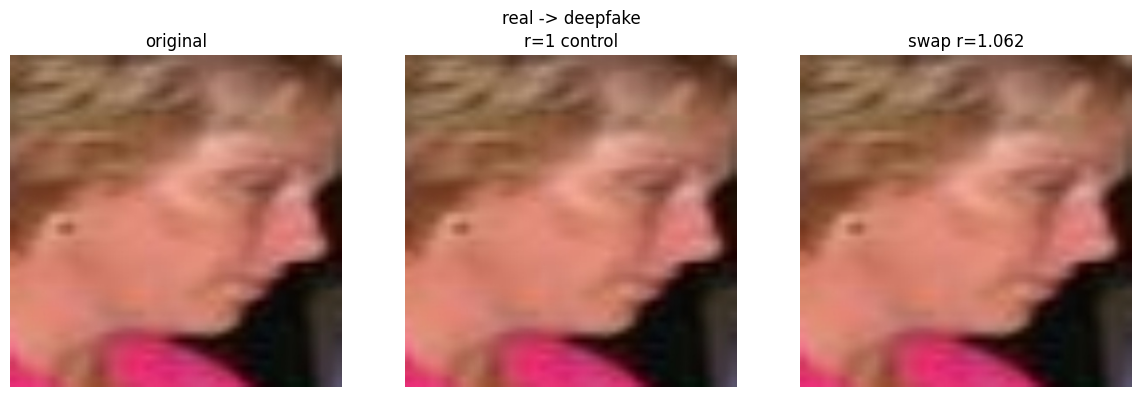

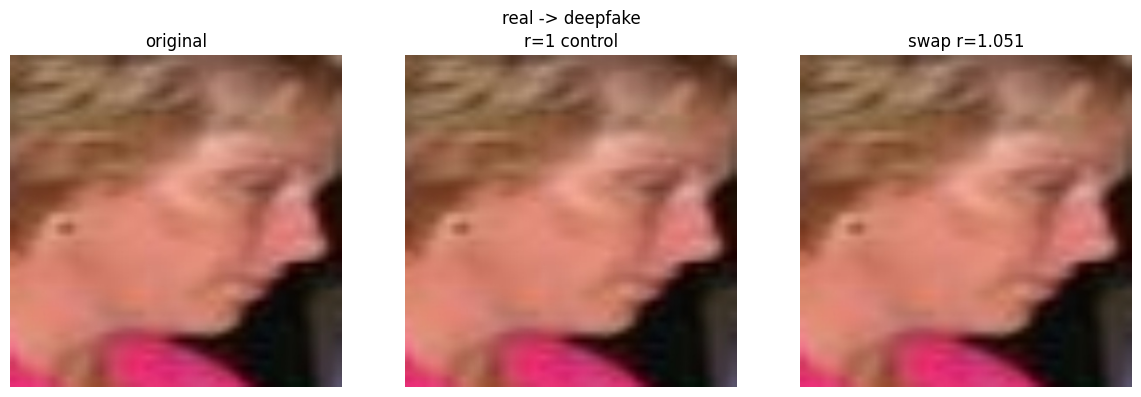

In [28]:
source_cls, target_cls = "real", "deepfake"
sample_idx = indices_by_class[source_cls][0]
sample = dataset[sample_idx]
raw01 = _load_raw01(sample["path"])

ratio = MEDIAN_UPSCALE_FACTOR[target_cls] / MEDIAN_UPSCALE_FACTOR[source_cls]
control = resize_roundtrip(raw01, 1.0)
swapped = resize_roundtrip(raw01, ratio)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img, title in zip(
    axes, [raw01, control, swapped], ["original", "r=1 control", f"swap r={ratio:.3f}"]
):
    ax.imshow(img.permute(1, 2, 0).numpy())
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(f"{source_cls} -> {target_cls}")
fig.tight_layout()

## Run the probe on a few held-out samples

`PROBE_N` samples per achievable *source* class (`real`, `deepfake` -- `edited` is never a source, only a target, since it has the highest measured median upscale factor and the round-trip can only add blur). For each, both the `r=1` control and the real factor-swap prediction are recorded per achievable target class.

In [29]:
PROBE_N = 30

results = run_probe(model, dataset, indices_by_class, PROBE_N)
len(results)


[real] /content/drive/MyDrive/deepfake/dataset/val/real/real_01612_00000.jpg
  baseline      : pred=     real  probs=real=0.902, edited=0.098, deepfake=0.000
  -> deepfake (r=1.051)
       control (r=1): pred=     real  probs=real=0.902, edited=0.098, deepfake=0.000
       swap         : pred=     real  probs=real=0.616, edited=0.384, deepfake=0.000
  -> edited (r=1.520)
       control (r=1): pred=     real  probs=real=0.902, edited=0.098, deepfake=0.000
       swap         : pred=     real  probs=real=0.778, edited=0.222, deepfake=0.000

[real] /content/drive/MyDrive/deepfake/dataset/val/real/real_01158_00001.jpg
  baseline      : pred=     real  probs=real=0.999, edited=0.001, deepfake=0.000
  -> deepfake (r=1.051)
       control (r=1): pred=     real  probs=real=0.999, edited=0.001, deepfake=0.000
       swap         : pred=     real  probs=real=0.999, edited=0.001, deepfake=0.000
  -> edited (r=1.520)
       control (r=1): pred=     real  probs=real=0.999, edited=0.001, deepfake=0

60

## Inspect one sample in detail

Re-run with a different index into `results` to look at other probed images.

In [30]:
r = results[0]
print("path:", r["path"])
print("true_class:", r["true_class"])
print("baseline:", r["baseline"])
print()
for target_cls, swap in r["resolution_swaps"].items():
    print(f"-- -> {target_cls} (r={swap['ratio']:.3f}) --")
    print("  control (r=1):", swap["control"])
    print("  swap         :", swap["swap"])

path: /content/drive/MyDrive/deepfake/dataset/val/real/real_01612_00000.jpg
true_class: real
baseline: {'pred': 'real', 'probs': {'real': 0.9021515846252441, 'edited': 0.09782854467630386, 'deepfake': 1.9862216504407115e-05}, 'gate': {'spatial': 0.2869914472103119, 'spectral': 0.3334777355194092, 'noise_residual': 0.37953078746795654}}

-- -> deepfake (r=1.051) --
  control (r=1): {'pred': 'real', 'probs': {'real': 0.9021515846252441, 'edited': 0.09782854467630386, 'deepfake': 1.9862216504407115e-05}, 'gate': {'spatial': 0.2869914472103119, 'spectral': 0.3334777355194092, 'noise_residual': 0.37953078746795654}}
  swap         : {'pred': 'real', 'probs': {'real': 0.6155076026916504, 'edited': 0.3844711184501648, 'deepfake': 2.1258128981571645e-05}, 'gate': {'spatial': 0.2844046950340271, 'spectral': 0.3384507894515991, 'noise_residual': 0.37714454531669617}}
-- -> edited (r=1.520) --
  control (r=1): {'pred': 'real', 'probs': {'real': 0.9021515846252441, 'edited': 0.09782854467630386, '

## Summary

Mean delta in `P(target_class)` is measured *swap vs its matched `r=1` control*, not vs raw baseline -- the control is the correct reference point since it isolates the resize-roundtrip-only effect from the deliberate factor increase. `flip_fraction` is how often `pred` actually flips to `target_class` under the real swap but not under the control.

In [31]:
summary = summarize(results)
print_summary(summary)


=== Summary: mean delta in P(target_class), real swap vs matched r=1 control ===
    target  mean_delta_p_target  flip_fraction     n
  deepfake              -0.0257          0.000    30
    edited               0.0308          0.017    60


## Breakdown by source->target pair

`summarize()` pools every source feeding a given target -- e.g. `real->edited` and `deepfake->edited` both land under `target=edited`. That can hide one source pair driving the whole pooled average. This reruns the same delta/flip computation keyed by `(source_class, target_class)` instead, so each pair can be read off separately.

In [32]:
summary_by_source = summarize_by_source(results)
print_summary_by_source(summary_by_source)


=== Breakdown by source->target pair (does one pair drive the pooled target average?) ===
            pair  mean_delta_p_target  flip_fraction     n
  real->deepfake              -0.0257          0.000    30
    real->edited               0.0613          0.033    30
deepfake->edited               0.0003          0.000    30


## Save (optional)

Only run once satisfied with `PROBE_N` -- writes to `EVAL_DIR`.

In [33]:
save_probe_results(results, summary, summary_by_source)


Saved probe results -> /content/drive/MyDrive/deepfake/eval/resolution_swap_probe_20260728T023851Z.json


PosixPath('/content/drive/MyDrive/deepfake/eval/resolution_swap_probe_20260728T023851Z.json')